# Chapter 46: Segmentation Architectures

**Which threshold and post-processing rule is best depends on how Dice is averaged: how large is that effect, and when does it appear?**

The chapter asks to specify the Dice reduction and the empty-target behaviour before reporting a score. In a competition with many empty images that choice decides which threshold wins, so a model compared under the wrong reduction is ranked under the wrong rule.

*Constructed data and a generated probability map; the sizes of these effects are properties of this generator, not a competition result.*

## The experiment

Constructed 32 x 32 images with one disc each (radius 2 to 8 pixels), where the control sets the share of images with no disc. A stand-in for a trained network supplies the probability map: the blurred mask plus spatially smooth noise, so small objects are weak and empty images carry speckle. Three rules are chosen on 150 development images: the threshold that maximises pooled Dice, the threshold that maximises mean per-image Dice (an empty prediction on an empty image scores 1), and a threshold plus a minimum object size (0, 5, 10 or 20 pixels, via connected components) for per-image Dice. Each is scored on 300 held-out images with both reductions, averaged over 10 draws.

In [1]:
import numpy as np
from scipy import ndimage

from kaggle_companion.activities._common import clean

SEED = 46
DRAWS = 10                 # independent image sets; every estimate is a mean over draws
SIZE = 32                  # images are 32 x 32 pixels
N_DEV, N_HELD = 150, 300   # development images (choose the rule) and held-out images (score it)
THRESHOLDS = np.linspace(0.2, 0.9, 15)
AREAS = (0, 5, 10, 20)     # minimum object sizes in pixels tried by the post-processing rule


def generate(n, empty_share, rng):
    """Masks with one disc each (radius 2 to 8 px; a share of the images is empty) and a stand-in model's probability map.
    The map is the blurred mask plus spatially smooth noise, so it misses small objects and speckles over empty images."""
    yy, xx = np.mgrid[:SIZE, :SIZE]
    masks = np.zeros((n, SIZE, SIZE), bool)
    for i in np.where(rng.random(n) >= empty_share)[0]:
        radius = rng.choice([2, 3, 4, 6, 8], p=[0.25, 0.25, 0.2, 0.15, 0.15])
        cy, cx = rng.integers(radius + 1, SIZE - radius - 1, 2)
        masks[i] = (yy - cy) ** 2 + (xx - cx) ** 2 <= radius ** 2
    blur = ndimage.gaussian_filter(masks.astype(float), (0, 1.2, 1.2))
    field = ndimage.gaussian_filter(rng.normal(size=masks.shape), (0, 1.5, 1.5))
    field /= field.std()
    return masks, 1 / (1 + np.exp(-(9 * (blur - 0.35) + 1.44 * field - 1.0)))


def pooled_dice(pred, target):
    """Intersection and support summed over the whole set, then one ratio."""
    return (2 * (pred & target).sum() + 1e-6) / (pred.sum() + target.sum() + 1e-6)


def image_dice(pred, target):
    """One ratio per image, averaged later. An empty target with an empty prediction scores 1 (the rule stated in the text)."""
    inter = (pred & target).sum((1, 2))
    total = pred.sum((1, 2)) + target.sum((1, 2))
    return np.where(total == 0, 1.0, 2 * inter / np.maximum(total, 1))


def remove_small(pred, area):
    """Delete connected components smaller than `area` pixels."""
    if area == 0:
        return pred
    out = pred.copy()
    for i in np.where(pred.any((1, 2)))[0]:
        labels, count = ndimage.label(pred[i])
        for k, size in enumerate(ndimage.sum(pred[i], labels, range(1, count + 1)), 1):
            if size < area:
                out[i][labels == k] = False
    return out


def run(empty_share):
    rng = np.random.default_rng(SEED)
    keys = ("pooled_rule", "image_rule", "area_rule")
    rows = {k: {"pooled": [], "image": []} for k in keys}
    chosen = {"pooled_rule": [], "image_rule": [], "area_rule": [], "area": []}
    curve_pooled, curve_image = [], []
    for _ in range(DRAWS):
        dev_mask, dev_prob = generate(N_DEV, empty_share, rng)
        held_mask, held_prob = generate(N_HELD, empty_share, rng)
        # Rule 1: the threshold that maximises pooled Dice on the development images.
        t_pooled = THRESHOLDS[np.argmax([pooled_dice(dev_prob > t, dev_mask) for t in THRESHOLDS])]
        # Rule 2: the threshold that maximises mean per-image Dice (empty rule included).
        t_image = THRESHOLDS[np.argmax([image_dice(dev_prob > t, dev_mask).mean() for t in THRESHOLDS])]
        # Rule 3: threshold and minimum object size that maximise mean per-image Dice.
        best = max(((image_dice(remove_small(dev_prob > t, a), dev_mask).mean(), t, a) for a in AREAS for t in THRESHOLDS[::2]),
                   key=lambda s: s[0])
        preds = {"pooled_rule": held_prob > t_pooled, "image_rule": held_prob > t_image,
                 "area_rule": remove_small(held_prob > best[1], best[2])}
        for k, pred in preds.items():
            rows[k]["pooled"].append(pooled_dice(pred, held_mask))
            rows[k]["image"].append(image_dice(pred, held_mask).mean())
        chosen["pooled_rule"].append(t_pooled)
        chosen["image_rule"].append(t_image)
        chosen["area_rule"].append(best[1])
        chosen["area"].append(best[2])
        curve_pooled.append([pooled_dice(held_prob > t, held_mask) for t in THRESHOLDS])
        curve_image.append([image_dice(held_prob > t, held_mask).mean() for t in THRESHOLDS])
    gain = np.array(rows["area_rule"]["image"]) - np.array(rows["pooled_rule"]["image"])
    return clean({
        "empty_share": empty_share,
        "rules": {k: {"pooled": np.mean(v["pooled"]), "image": np.mean(v["image"])} for k, v in rows.items()},
        "threshold": {k: np.mean(chosen[k]) for k in keys}, "min_area": np.mean(chosen["area"]),
        "gain_image": gain.mean(), "gain_se": gain.std(ddof=1) / np.sqrt(DRAWS), "win_rate": float((gain > 0).mean()),
        "thresholds": THRESHOLDS, "curve_pooled": np.mean(curve_pooled, 0), "curve_image": np.mean(curve_image, 0),
        "draws": DRAWS, "dev_images": N_DEV, "held_images": N_HELD,
    })


## Measure it across the control

The control is **share of images with an empty mask**. Each value below runs the whole experiment from the generator up.

In [2]:
import pandas as pd
from kaggle_companion.activities.ch46 import explain

VALUES = [0, 0.25, 0.5, 0.75]
results = {value: run(value) for value in VALUES}
table = pd.DataFrame({str(v): explain(results[v], v)['metrics'] for v in VALUES})
print(table.to_string())

                                                0            0.25             0.5            0.75
Pooled rule, per-image Dice                 0.817           0.744           0.723           0.728
Pooled rule, pooled Dice                    0.905           0.901           0.894           0.876
Per-image rule, per-image Dice              0.822           0.765           0.801           0.866
Minimum-size rule, per-image Dice           0.831           0.833           0.872           0.922
Minimum-size rule, pooled Dice              0.909           0.908           0.903           0.899
Gain over pooled rule (SE)         +0.013 (0.002)  +0.090 (0.006)  +0.149 (0.009)  +0.194 (0.018)


## Look at it

The figure shows the default setting, share of images with an empty mask = 0.5.

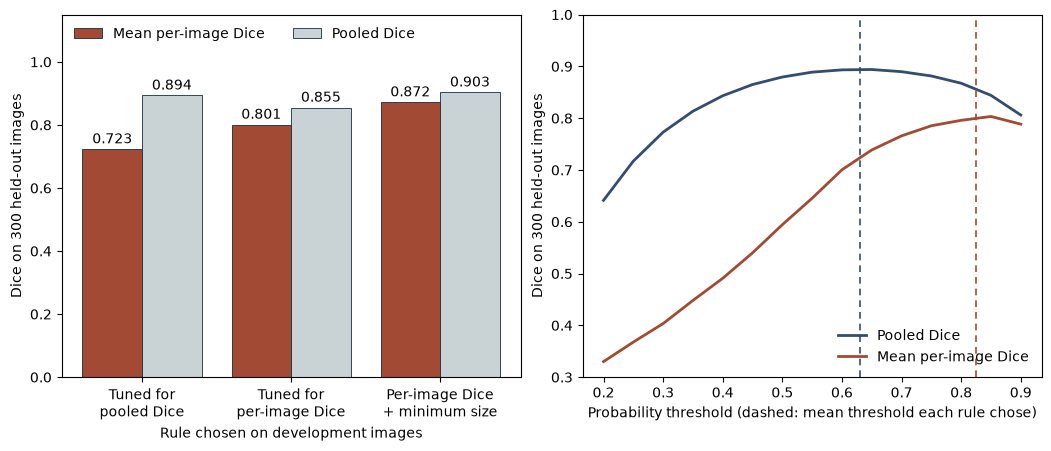

In [3]:
import matplotlib.pyplot as plt
from kaggle_companion.activities.ch46 import draw, NCOLS, HEIGHT

DEFAULT = 0.5
fig, axes = plt.subplots(1, NCOLS, figsize=(6.6 if NCOLS == 1 else 10.4, HEIGHT), layout='constrained')
draw(axes, results[DEFAULT], DEFAULT)
plt.show()

## What the result says

With 50% of images empty, the threshold tuned for pooled Dice (0.630) scores pooled Dice 0.894 but mean per-image Dice 0.723. Tuning for per-image Dice moves the threshold to 0.825 and gives 0.801 per image and 0.855 pooled. Adding a minimum object size (mean 7.0 pixels) reaches 0.872 per image: 0.872 - 0.723 = 0.149 over the pooled-Dice rule (standard error 0.009, better in 100% of draws).

- Pooled-Dice rule, per-image minus pooled: 0.723 - 0.894 = -0.171.
- Per-image rule, pooled Dice: 0.855 - 0.894 = -0.039 against the pooled rule.
- Minimum-size rule over the pooled-Dice rule, per image: 0.872 - 0.723 = +0.149.
- Thresholds chosen: pooled 0.630, per-image 0.825, with minimum size 0.590.

## Apply this to your competition

- Write the official Dice reduction and the empty-mask rule into the validation code before comparing any model.
- Choose the threshold, and a minimum object size if the host scores per image, on development images, then freeze both.
- Report the share of empty images and the score on empty and non-empty images separately.
- Check the minimum-size rule against false positives that are large, not only speckle.

Book location: Chapter 46, Segmentation Losses.

[Technical corrections](https://github.com/KarpelesPublishing/winning-kaggle-companion/blob/main/docs/errata.md)